# Spectral Analysis (Baseline vs Edited)

This notebook loads the latest structural result from `analysis_out/` and compares each test to baseline.

- Uses spectral outputs (`baseline_spectral` / `spectral_detection`)
- Falls back to blind detector outputs when spectral fields are absent

In [6]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root() -> Path:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / 'analysis_out').exists():
            return candidate
    return cwd


ROOT = find_repo_root()
ANALYSIS_DIR = ROOT / 'analysis_out'
RUN_FILES = sorted(
    list(ANALYSIS_DIR.glob('*.json')) + list(ANALYSIS_DIR.glob('*.jsxn')),
    key=lambda p: p.stat().st_mtime,
)
if not RUN_FILES:
    raise FileNotFoundError(f'No run files in {ANALYSIS_DIR}')

RUN_PATH = RUN_FILES[-1]
print(f'Using run file: {RUN_PATH}')

with open(RUN_PATH, 'r') as f:
    data = json.load(f)

meta = data.get('metadata', {})
target_layer = meta.get('target_layer')
print('Model:', meta.get('model'))
print('Target layer:', target_layer)
print('Top-level keys:', list(data.keys()))


def to_int_float_map(d):
    return {int(k): float(v) for k, v in (d or {}).items()}

Using run file: /home/metju/reimagined/analysis_out/rome_structural_gpt2-large_2026-02-23_15-54-46.json
Model: gpt2-large
Target layer: 12
Top-level keys: ['metadata', 'baseline_blind', 'baseline_spectral', 'baseline_interlayer', 'tests', 'summary']


In [7]:
mode = 'unknown'
baseline_block = {}
test_key = None
signal_key = 'sv_z_scores'
correct_key = None

if data.get('baseline_spectral', {}).get('sv_z_scores') or data.get('baseline_spectral_bin', {}).get('sv_z_scores'):
    mode = 'spectral'
    baseline_block = data.get('baseline_spectral', data.get('baseline_spectral_bin', {}))
    test_key = 'spectral_detection' if any(t.get('spectral_detection') for t in data.get('tests', [])) else 'spectral_bin_detection'
    correct_key = 'spectral_correct'
else:
    mode = 'blind'
    baseline_block = data.get('baseline_blind', {})
    test_key = 'blind_detection'
    signal_key = 'isolation_scores'
    correct_key = 'blind_correct'

baseline_scores = to_int_float_map(baseline_block.get(signal_key, {}))
if not baseline_scores:
    raise ValueError(f'No baseline scores found for key {signal_key}')

evaluated_layers = [int(l) for l in baseline_block.get('evaluated_layers', [])]
layers = evaluated_layers if evaluated_layers else sorted(baseline_scores.keys())
baseline_arr = np.array([baseline_scores.get(l, np.nan) for l in layers], dtype=float)

rows = []
for test in data.get('tests', []):
    if test.get('skipped', False):
        continue

    block = test.get(test_key, {})
    scores = to_int_float_map(block.get(signal_key, {}))
    if not scores:
        continue

    correct = test.get('accuracy', {}).get(correct_key)

    arr = np.array([scores.get(l, np.nan) for l in layers], dtype=float)
    rows.append(
        {
            'case_id': test.get('case_id', 'N/A'),
            'subject': test.get('subject', ''),
            'scores': arr,
            'anomalous_layer': block.get('anomalous_layer'),
            'detection_score': block.get('detection_score', block.get('layer_anomaly_score', np.nan)),
            'correct': correct,
            'raw_block': block,
        }
    )

print(f'Mode: {mode}')
print(f'Layers used: {len(layers)} | tests with usable scores: {len(rows)}')

Mode: spectral
Layers used: 32 | tests with usable scores: 0


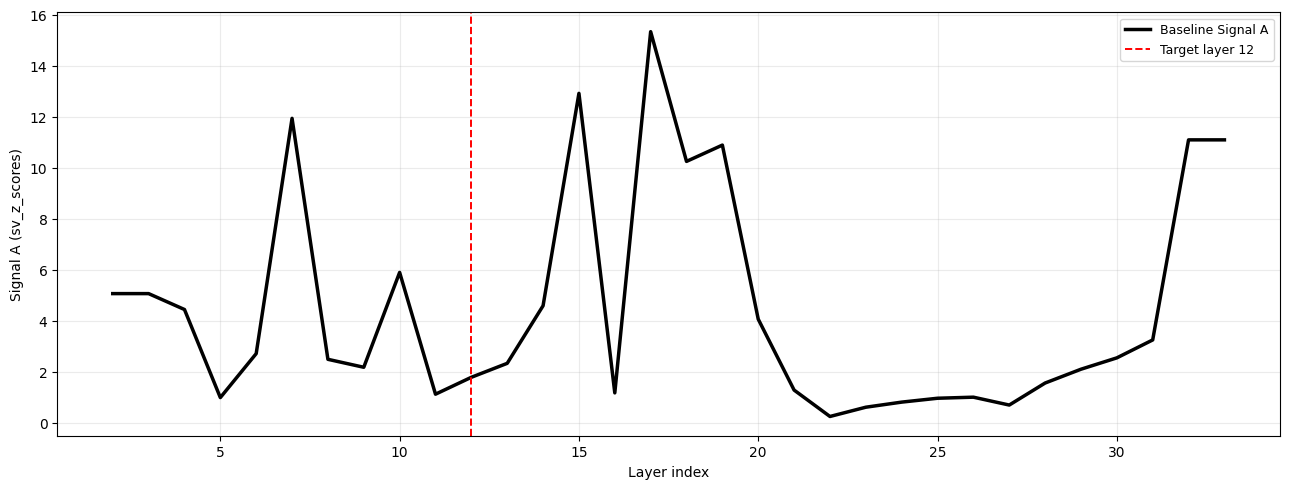

In [8]:
plt.figure(figsize=(13, 5))
plt.plot(layers, baseline_arr, color='black', linewidth=2.5, label='Baseline Signal A')

for r in rows:
    plt.plot(layers, r['scores'], alpha=0.45, linewidth=1.5, label=f"Test {r['case_id']}")

if target_layer is not None:
    plt.axvline(target_layer, color='red', linestyle='--', linewidth=1.4, label=f'Target layer {target_layer}')
plt.xlabel('Layer index')
plt.ylabel('Signal A (sv_z_scores)')
if len(rows) <= 10:
    plt.legend(fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
if rows:
    delta_matrix = np.vstack([r['scores'] - baseline_arr for r in rows])
    max_abs = np.nanmax(np.abs(delta_matrix)) if np.isfinite(delta_matrix).any() else 1.0
    max_abs = max(max_abs, 1e-6)

    fig, ax = plt.subplots(figsize=(13, max(2.5, 0.65 * len(rows))))
    im = ax.imshow(delta_matrix, aspect='auto', cmap='coolwarm', vmin=-max_abs, vmax=max_abs)

    ax.set_title(f'Test - Baseline Signal A delta ({mode})')
    ax.set_xlabel('Layer index')
    ax.set_ylabel('Test case')

    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels([str(r['case_id']) for r in rows])

    step = max(1, len(layers) // 12)
    tick_idx = np.arange(0, len(layers), step)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([layers[i] for i in tick_idx])

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Delta Signal A')
    plt.tight_layout()
    plt.show()
else:
    print('No usable tests for delta heatmap.')

No usable tests for delta heatmap.


In [10]:
if mode != 'spectral':
    print('Signal breakdown skipped: spectral fields not available in this run file.')
elif not rows:
    print('No usable tests for signal breakdown.')
else:
    selected = rows[0]
    block = selected['raw_block']

    base_z = to_int_float_map(baseline_block.get('sv_z_scores', {}))
    test_z = to_int_float_map(block.get('sv_z_scores', {}))
    z_base_arr = np.array([base_z.get(l, np.nan) for l in layers], dtype=float)
    z_test_arr = np.array([test_z.get(l, np.nan) for l in layers], dtype=float)

    base_ratio = to_int_float_map(baseline_block.get('sv_ratio_scores', {}))
    test_ratio = to_int_float_map(block.get('sv_ratio_scores', {}))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(layers, z_base_arr, color='black', linewidth=2, label='Baseline sv_z')
    axes[0].plot(layers, z_test_arr, color='tab:blue', alpha=0.85, label=f"Test {selected['case_id']} sv_z")
    if target_layer is not None:
        axes[0].axvline(target_layer, color='red', linestyle='--', linewidth=1.2)
    axes[0].set_title('Signal A: sv_z_scores')
    axes[0].set_xlabel('Layer')
    axes[0].set_ylabel('Second-derivative energy')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=9)

    has_ratio = bool(base_ratio) and bool(test_ratio) and (np.isfinite(list(base_ratio.values())).any())
    if has_ratio:
        ratio_base_arr = np.array([base_ratio.get(l, np.nan) for l in layers], dtype=float)
        ratio_test_arr = np.array([test_ratio.get(l, np.nan) for l in layers], dtype=float)
        axes[1].plot(layers, ratio_base_arr, color='black', linewidth=2, label='Baseline sv_ratio')
        axes[1].plot(layers, ratio_test_arr, color='tab:green', alpha=0.85, label=f"Test {selected['case_id']} sv_ratio")
        if target_layer is not None:
            axes[1].axvline(target_layer, color='red', linestyle='--', linewidth=1.2)
        axes[1].set_title('Signal B: sv_ratio_scores')
        axes[1].set_xlabel('Layer')
        axes[1].set_ylabel('Second-derivative energy')
        axes[1].grid(alpha=0.25)
        axes[1].legend(fontsize=9)
    else:
        axes[1].text(0.5, 0.5, 'No sv_ratio_scores available in this run', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()

No usable tests for signal breakdown.
